# Product demand analysis

In [116]:
import pandas as pd
import numpy as np
import seaborn as sns
df=pd.read_csv('Amazon_Products_fixed.csv')
df.head()

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Microphones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Chargers & Power,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Microphones,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Headphones & Earbuds,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Networking & Smart Home,0.00


In [117]:
df.describe()

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage
count,41651.000000,41651.000000,32164.000000,40613.000000,40613.000000,40613.000000
mean,4.399431,3087.106000,1293.665278,243.227289,257.611107,6.547151
std,0.386997,13030.460133,6318.323574,473.351545,496.633495,12.744715
min,1.000000,1.000000,50.000000,2.160000,2.160000,0.000000
25%,4.200000,82.000000,100.000000,29.690000,32.990000,0.000000
50%,4.500000,343.000000,200.000000,84.990000,89.000000,0.000000
75%,4.700000,1886.000000,400.000000,224.000000,229.990000,8.490000
max,5.000000,865598.000000,100000.000000,5449.000000,5449.000000,85.420000


In [118]:
df=df.drop(columns=['product_image_url','product_page_url'])
df.head()


,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,2025-08-21 11:14:29,Microphones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,2025-08-21 11:14:29,Chargers & Power,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,2025-08-21 11:14:29,Microphones,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,2025-08-21 11:14:29,Headphones & Earbuds,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,2025-08-21 11:14:29,Networking & Smart Home,0.00


Here, we removed columns that are not relevant for our analysis: `product_image_url`and `product_page_url`, . These are metadata columns that do not contribute to understanding product characteristics or performance. Dropping them simplifies the dataset and reduces memory usage.

In [119]:
df['product_rating']=df['product_rating'].astype(str)
quantiative_features=df.select_dtypes(include=[np.number])
print("Quantivative features : ",quantiative_features.columns.to_list())

qualitative_features=df.select_dtypes(exclude=[np.number])
print("Qualitative features : ",qualitative_features.columns.tolist())

Quantivative features :  ['total_reviews', 'purchased_last_month', 'discounted_price', 'original_price', 'discount_percentage']
Qualitative features :  ['product_title', 'product_rating', 'is_best_seller', 'is_sponsored', 'has_coupon', 'buy_box_availability', 'delivery_date', 'sustainability_tags', 'data_collected_at', 'product_category']


In this step, we classified the features into **quantitative** (numeric) and **qualitative** (non-numeric) categories. The `select_dtypes(include=[np.number])` method extracts all numeric columns, while `select_dtypes(exclude=[np.number])` extracts non-numeric columns. This classification helps us understand which statistical methods are appropriate for each feature type.

In [120]:
print(df.dtypes)

product_title            object
product_rating           object
total_reviews           float64
purchased_last_month    float64
discounted_price        float64
original_price          float64
is_best_seller           object
is_sponsored             object
has_coupon               object
buy_box_availability     object
delivery_date            object
sustainability_tags      object
data_collected_at        object
product_category         object
discount_percentage     float64
dtype: object


Using `df.dtypes`, we printed the data type of each column. This helps us verify whether columns are stored as the correct type (integer, float, object, etc.) and identify any columns that may need type conversion for proper analysis.

In [121]:
df['product_rating']=pd.to_numeric(df['product_rating'], errors='coerce')
df = df.apply(pd.to_numeric, errors='ignore')
print(df.dtypes)

product_title            object
product_rating          float64
total_reviews           float64
purchased_last_month    float64
discounted_price        float64
original_price          float64
is_best_seller           object
is_sponsored             object
has_coupon               object
buy_box_availability     object
delivery_date            object
sustainability_tags      object
data_collected_at        object
product_category         object
discount_percentage     float64
dtype: object


C:\Users\USER\AppData\Local\Temp\ipykernel_17160\3873699148.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


We converted columns to their appropriate numeric data types using `pd.to_numeric()`. The `errors='coerce'` parameter converts invalid values to NaN instead of raising an error, while `errors='ignore'` keeps non-convertible columns unchanged. This ensures that numeric operations can be performed correctly on the data.

In [122]:

nominal = ['product_title', 'is_best_seller', 'is_sponsored', 'has_coupon', 
           'buy_box_availability', 'sustainability_tags', 'product_category']

ordinal = ['product_rating']  

interval = [] 

ratio = ['total_reviews', 'purchased_last_month', 'discounted_price', 
         'original_price', 'discount_percentage']

print("4 LEVELS OF DATA CLASSIFICATION")
print(f"\n1. NOMINAL (No order):\n   {nominal}")
print(f"\n2. ORDINAL (Ordered):\n   {ordinal}")
print(f"\n3. INTERVAL (No true zero):\n   {interval}")
print(f"\n4. RATIO (True zero):\n   {ratio}")

4 LEVELS OF DATA CLASSIFICATION

1. NOMINAL (No order):
   ['product_title', 'is_best_seller', 'is_sponsored', 'has_coupon', 'buy_box_availability', 'sustainability_tags', 'product_category']

2. ORDINAL (Ordered):
   ['product_rating']

3. INTERVAL (No true zero):
   []

4. RATIO (True zero):
   ['total_reviews', 'purchased_last_month', 'discounted_price', 'original_price', 'discount_percentage']


This code categorizes all features into the **four levels of data measurement**:

- **Nominal**: Categorical data with no inherent order (e.g., product_title, product_category)
- **Ordinal**: Categorical data with a meaningful order (e.g., product_rating with values 1-5)
- **Interval**: Numeric data with equal intervals but no true zero point (not present in this dataset)
- **Ratio**: Numeric data with equal intervals and a true zero point (e.g., price, count, discount)

This classification determines which statistical operations are valid for each feature.

In [123]:
numeric_df = df.select_dtypes(include=[np.number])
#print(numeric_df.to_string())

descriptive_stats = pd.DataFrame({
    'Mean': numeric_df.mean(),
    'Median': numeric_df.median(),
    'Mode': numeric_df.mode().iloc[0],
    'Q1 (25%)': numeric_df.quantile(0.25),
    'Q2 (50%)': numeric_df.quantile(0.50),
    'Q3 (75%)': numeric_df.quantile(0.75),
    'Std Dev': numeric_df.std(),
    'Min': numeric_df.min(),
    'Max': numeric_df.max()
})

print("DESCRIPTIVE STATISTICS FOR NUMERIC FEATURES")
descriptive_stats


DESCRIPTIVE STATISTICS FOR NUMERIC FEATURES


,Mean,Median,Mode,Q1 (25%),Q2 (50%),Q3 (75%),Std Dev,Min,Max
product_rating,4.399431,4.50,4.60,4.20,4.50,4.70,0.386997,1.00,5.00
total_reviews,3087.106000,343.00,25.00,82.00,343.00,1886.00,13030.460133,1.00,865598.00
purchased_last_month,1293.665278,200.00,100.00,100.00,200.00,400.00,6318.323574,50.00,100000.00
discounted_price,243.227289,84.99,29.99,29.69,84.99,224.00,473.351545,2.16,5449.00
original_price,257.611107,89.00,29.99,32.99,89.00,229.99,496.633495,2.16,5449.00
discount_percentage,6.547151,0.00,0.00,0.00,0.00,8.49,12.744715,0.00,85.42


We calculated **descriptive statistics** for all numeric features:

- **Mean**: The average value of the data
- **Median**: The middle value when data is sorted (also Q2)
- **Mode**: The most frequently occurring value
- **Q1 (25th percentile)**: Value below which 25% of data falls
- **Q2 (50th percentile)**: The median value
- **Q3 (75th percentile)**: Value below which 75% of data falls
- **Standard Deviation**: Measures how spread out the values are from the mean

These statistics provide insights into the central tendency, distribution, and variability of the data.

In [124]:
# import matplotlib.pyplot as plt

# numeric_cols = df.select_dtypes(include=[np.number]).columns

# fig, axes = plt.subplots(6, 1, figsize=(10, 30))
# axes = axes.flatten()  # Flatten to 1D array for easy indexing

# for i, col in enumerate(numeric_cols):  # This defines 'i' and 'col'
#     axes[i].hist(df[col].dropna(),bins=50)
#     axes[i].set_title(f'{col}\nSkewness: {df[col].skew():.2f}')
#     axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
#     axes[i].axvline(df[col].median(), color='green', label='Median')
#     axes[i].legend()


# plt.show()

# Histogram plots for all features

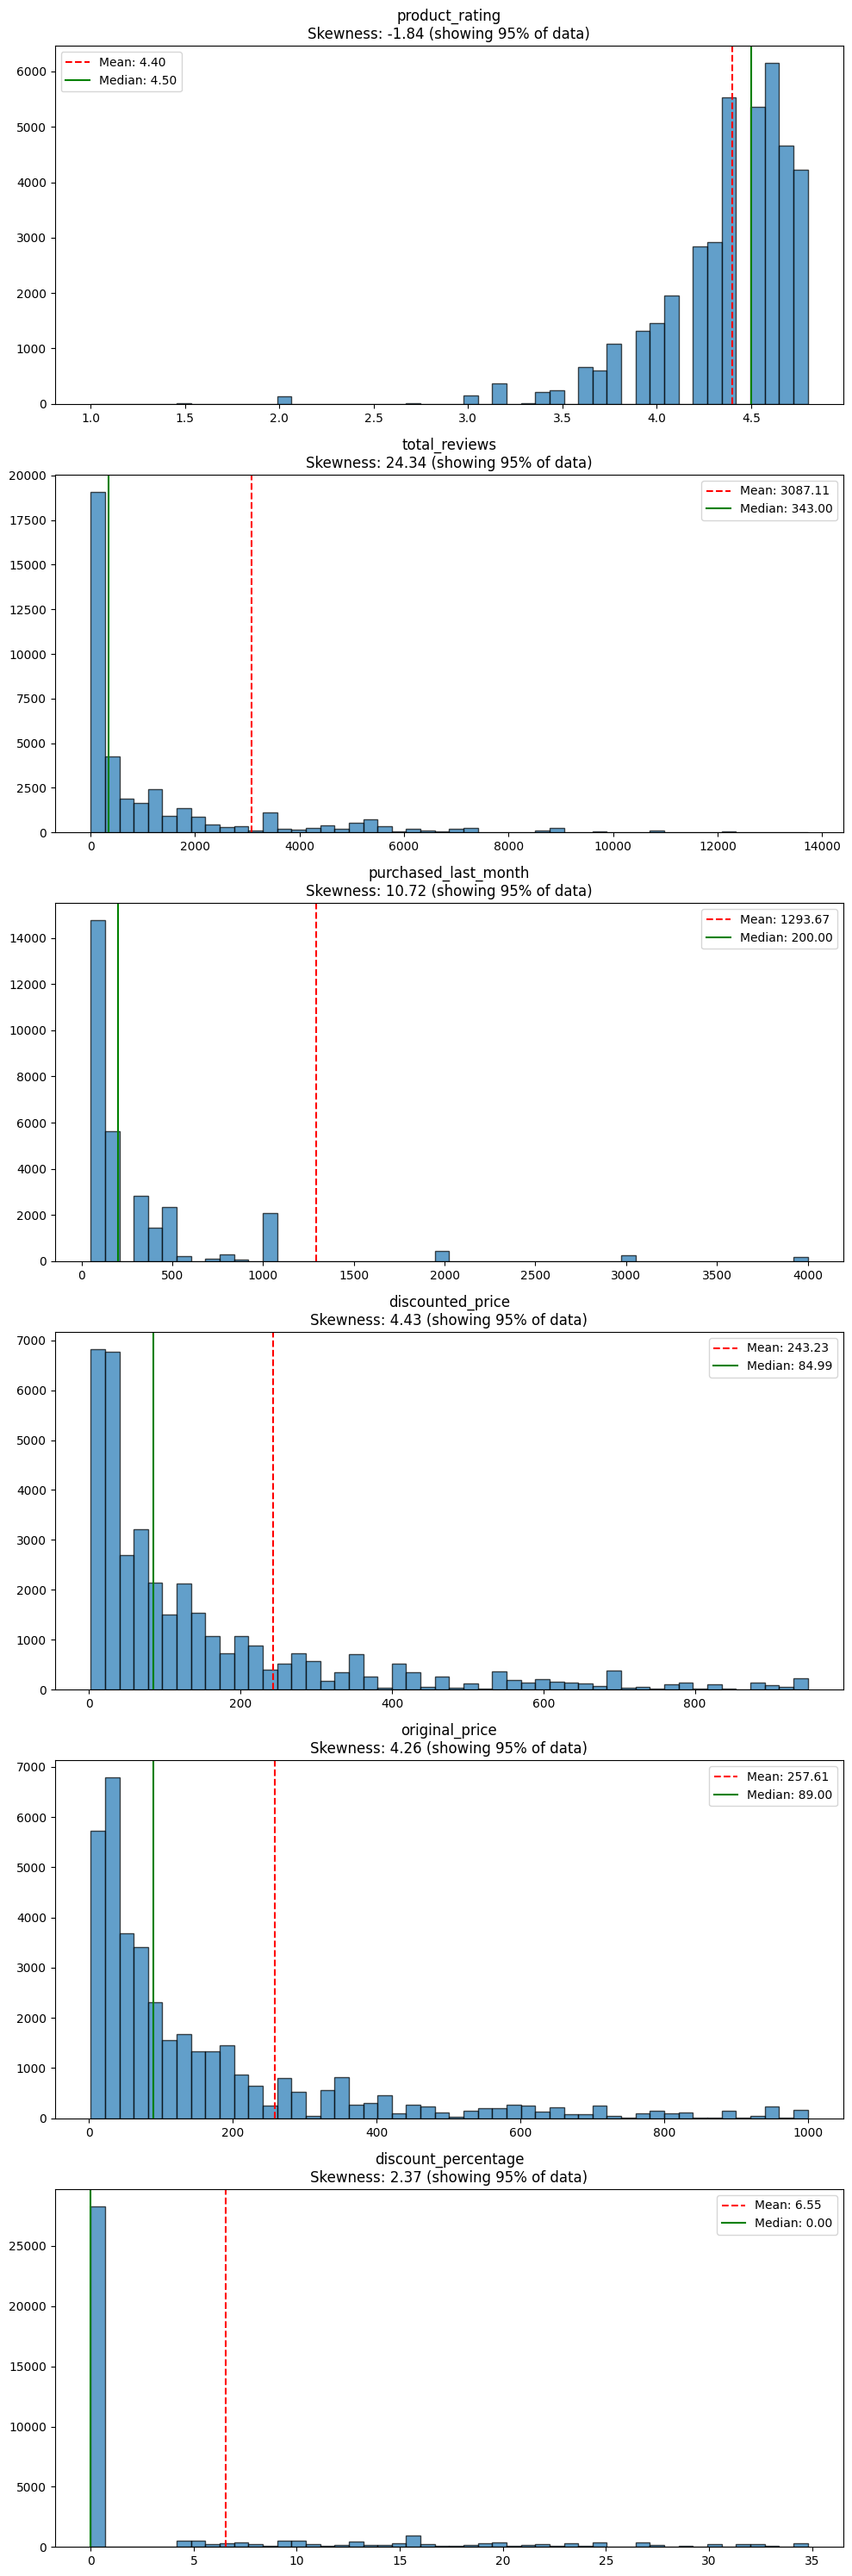

In [125]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=[np.number]).columns

fig, axes = plt.subplots(6, 1, figsize=(10, 30))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    
    # Filter to 95th percentile for better visualization
    upper_limit = data.quantile(0.95)
    filtered_data = data[data <= upper_limit]
    
    axes[i].hist(filtered_data, bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col}\nSkewness: {data.skew():.2f} (showing 95% of data)')
    
    # Only show mean/median if within visible range
    mean_val = data.mean()
    median_val = data.median()
    if mean_val <= upper_limit:
        axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    if median_val <= upper_limit:
        axes[i].axvline(median_val, color='green', label=f'Median: {median_val:.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [126]:
print(df.dtypes)
df['product_rating']=pd.to_numeric(df['product_rating'],errors='coerce')
print(df.dtypes)

product_title            object
product_rating          float64
total_reviews           float64
purchased_last_month    float64
discounted_price        float64
original_price          float64
is_best_seller           object
is_sponsored             object
has_coupon               object
buy_box_availability     object
delivery_date            object
sustainability_tags      object
data_collected_at        object
product_category         object
discount_percentage     float64
dtype: object
product_title            object
product_rating          float64
total_reviews           float64
purchased_last_month    float64
discounted_price        float64
original_price          float64
is_best_seller           object
is_sponsored             object
has_coupon               object
buy_box_availability     object
delivery_date            object
sustainability_tags      object
data_collected_at        object
product_category         object
discount_percentage     float64
dtype: object


# Missing Data

In [127]:
df.isnull().sum()

product_title               0
product_rating           1024
total_reviews            1024
purchased_last_month    10511
discounted_price         2062
original_price           2062
is_best_seller              0
is_sponsored                0
has_coupon                  0
buy_box_availability    14653
delivery_date           11983
sustainability_tags     39267
data_collected_at           0
product_category            0
discount_percentage      2062
dtype: int64

# Handling Missing Data

In [128]:
df.dropna(subset=['purchased_last_month'], inplace=True)

df['product_rating'].fillna(df['product_rating'].median(), inplace=True)

df['total_reviews'].fillna(df['total_reviews'].median(), inplace=True)

df['discount_percentage'].fillna(0,inplace=True)

calculated_original = df['discounted_price'] / (1 - df['discount_percentage']/100)
df['original_price'].fillna(calculated_original, inplace=True)
df['original_price'].fillna(df['original_price'].median(), inplace=True)

df['discounted_price']=df['original_price']-(df['discount_percentage']/100)*df['original_price']


df['buy_box_availability'].fillna("None",inplace=True)
df['sustainability_tags'].fillna("None",inplace=True)

df['delivery_date'] = df['delivery_date'].ffill
df.isnull().sum()

product_title           0
product_rating          0
total_reviews           0
purchased_last_month    0
discounted_price        0
original_price          0
is_best_seller          0
is_sponsored            0
has_coupon              0
buy_box_availability    0
delivery_date           0
sustainability_tags     0
data_collected_at       0
product_category        0
discount_percentage     0
dtype: int64

### 1. **purchased_last_month** - Deletion (`dropna`)
- Dropped all rows with missing values
- This is our **target variable** for demand prediction. Without it, these rows provide no value for our analysis. Imputation would be inappropriate as we cannot accurately estimate demand without actual data.

### 2. **product_rating** - Median Imputation
- Filled with median rating
- Median is robust to outliers and represents the "typical" rating. Using mean could be skewed by extreme ratings (1 or 5 stars). Median provides a conservative, middle-ground estimate.

### 3. **total_reviews** - Median Imputation
- Filled with median review count
- Review counts are often **heavily right-skewed** (few products have thousands of reviews). Median is more representative of typical products than mean, which would be inflated by viral/popular items.

### 4. **discount_percentage** - Zero Fill
- Filled with 0
- Missing discount percentage logically means **no discount was applied**. This is a domain-knowledge driven decision where absence of data implies absence of discount.

### 5. **original_price** - Calculated Imputation + Median Fallback
- 
  1. First, calculated from: `discounted_price / (1 - discount_percentage/100)`
  2. Then filled remaining with median
- When discount information exists, we can **mathematically derive** the original price. For remaining missing values, median provides a reasonable estimate without introducing extreme values.

### 6. **discounted_price** - Forward Fill with original_price
- Calculated using original price and discount percentage

### 7. **buy_box_availability** & **sustainability_tags** - "None" Fill
- Filled with string "None"
- These are categorical features where missing values indicate the **absence of that attribute** (no buy box, no sustainability certification). "None" explicitly marks this absence for analysis.

### 8. **delivery_date** - Forward Fill
- Forward fill (propagate last valid value)
- Delivery dates may follow temporal patterns. Forward filling assumes similar delivery timelines for consecutive products, though this column appears optional in the dataset.



# Handling Duplicates

In [129]:
print(df.duplicated().sum())
print(df.shape)
print("After dropping duplicates")
df.drop_duplicates(keep='first',inplace=True,ignore_index=True)
print(df.shape)


0
(32164, 15)
After dropping duplicates
(32164, 15)


The original dataset did not contained duplicate entries.
- Original rows: 32,164
- Clean dataset: 32,164 unique products

# Unique values analysis for categorical features

In [130]:
categorical_cols = ['product_category', 'is_best_seller', 'is_sponsored', 
                    'has_coupon', 'buy_box_availability', 'sustainability_tags']

print("UNIQUE VALUE ANALYSIS FOR CATEGORICAL FEATURES")

for col in categorical_cols:
    if col in df.columns:
        total = len(df[col])
        value_counts = df[col].value_counts()
        unique_count = df[col].nunique()
        dominant_pct = (value_counts.iloc[0] / total) * 100
        
        print(f"\n {col} | {unique_count} unique values | Dominant: {dominant_pct:.1f}%")
        print(f"{'Value':<45} {'Count':>7} {'%':>7}")
        
        display_values = value_counts if unique_count <= 20 else value_counts.head(10)
        
        for val, count in display_values.items():
            pct = (count / total) * 100
            print(f"{str(val):<45} {count:>7} {pct:>6.1f}%")
        
        if unique_count > 20:
            print(f"  ... and {unique_count - 10} more values")
        
        print(f"{'TOTAL':<45} {total:>7} {'100.0%':>7}")

UNIQUE VALUE ANALYSIS FOR CATEGORICAL FEATURES

 product_category | 22 unique values | Dominant: 13.1%
Value                                           Count       %
Chargers & Power                                 4212   13.1%
Other Electronics                                3828   11.9%
Batteries                                        2420    7.5%
Printers & Scanners                              2420    7.5%
Laptops & Computers                              2136    6.6%
Microphones                                      2044    6.4%
Cameras & Photography                            1999    6.2%
Gaming                                           1706    5.3%
Headphones & Earbuds                             1463    4.5%
Speakers & Audio                                 1458    4.5%
  ... and 12 more values
TOTAL                                           32164  100.0%

 is_best_seller | 9 unique values | Dominant: 94.7%
Value                                           Count       %
No Badge     

Here we can see the no of unique values for different categorical features

Index(['product_rating', 'total_reviews', 'purchased_last_month',
       'discounted_price', 'original_price', 'discount_percentage'],
      dtype='object')


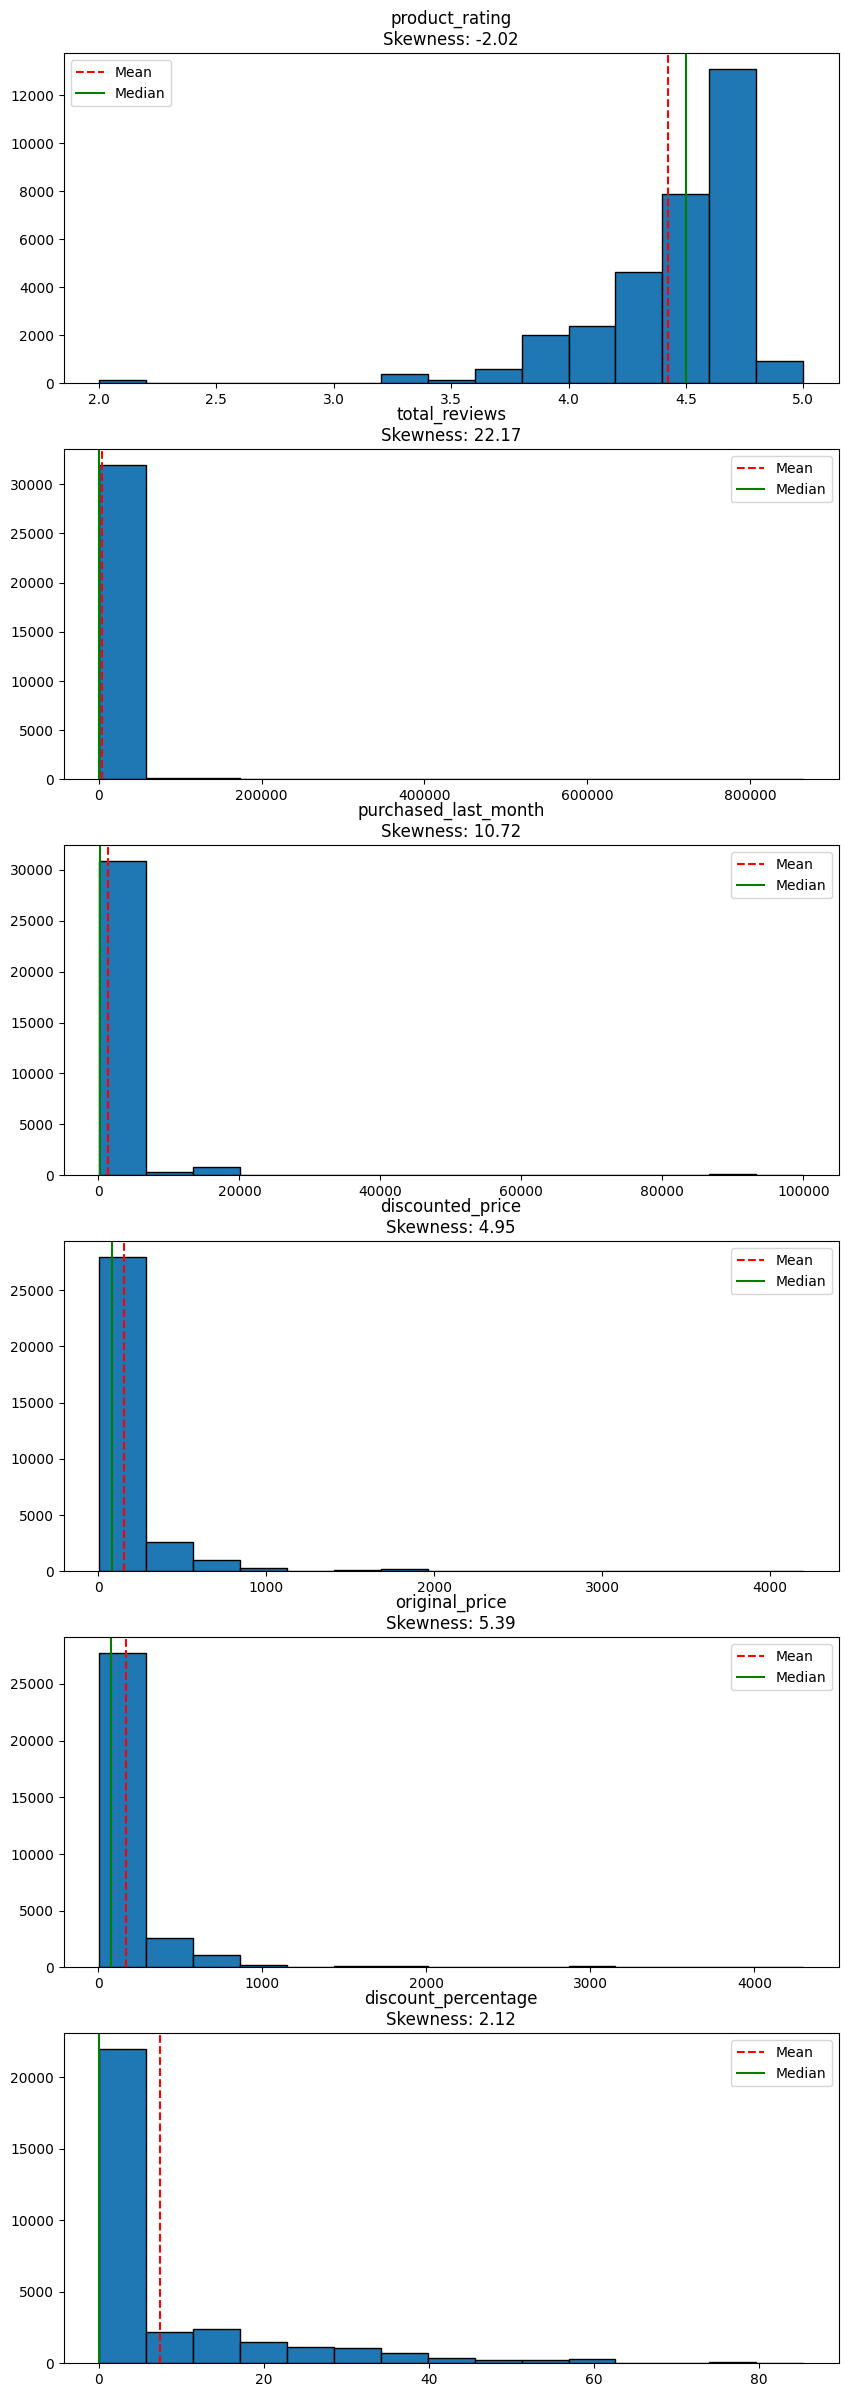

In [131]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=[np.number]).columns
print(numeric_cols)
fig, axes = plt.subplots(6, 1, figsize=(10, 30))
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i, col in enumerate(numeric_cols):  
    axes[i].hist(df[col],bins=15, edgecolor='black')
    axes[i].set_title(f'{col}\nSkewness: {df[col].skew():.2f}')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[i].axvline(df[col].median(), color='green', label='Median')
    axes[i].legend()


plt.show()

# Fining Outliers

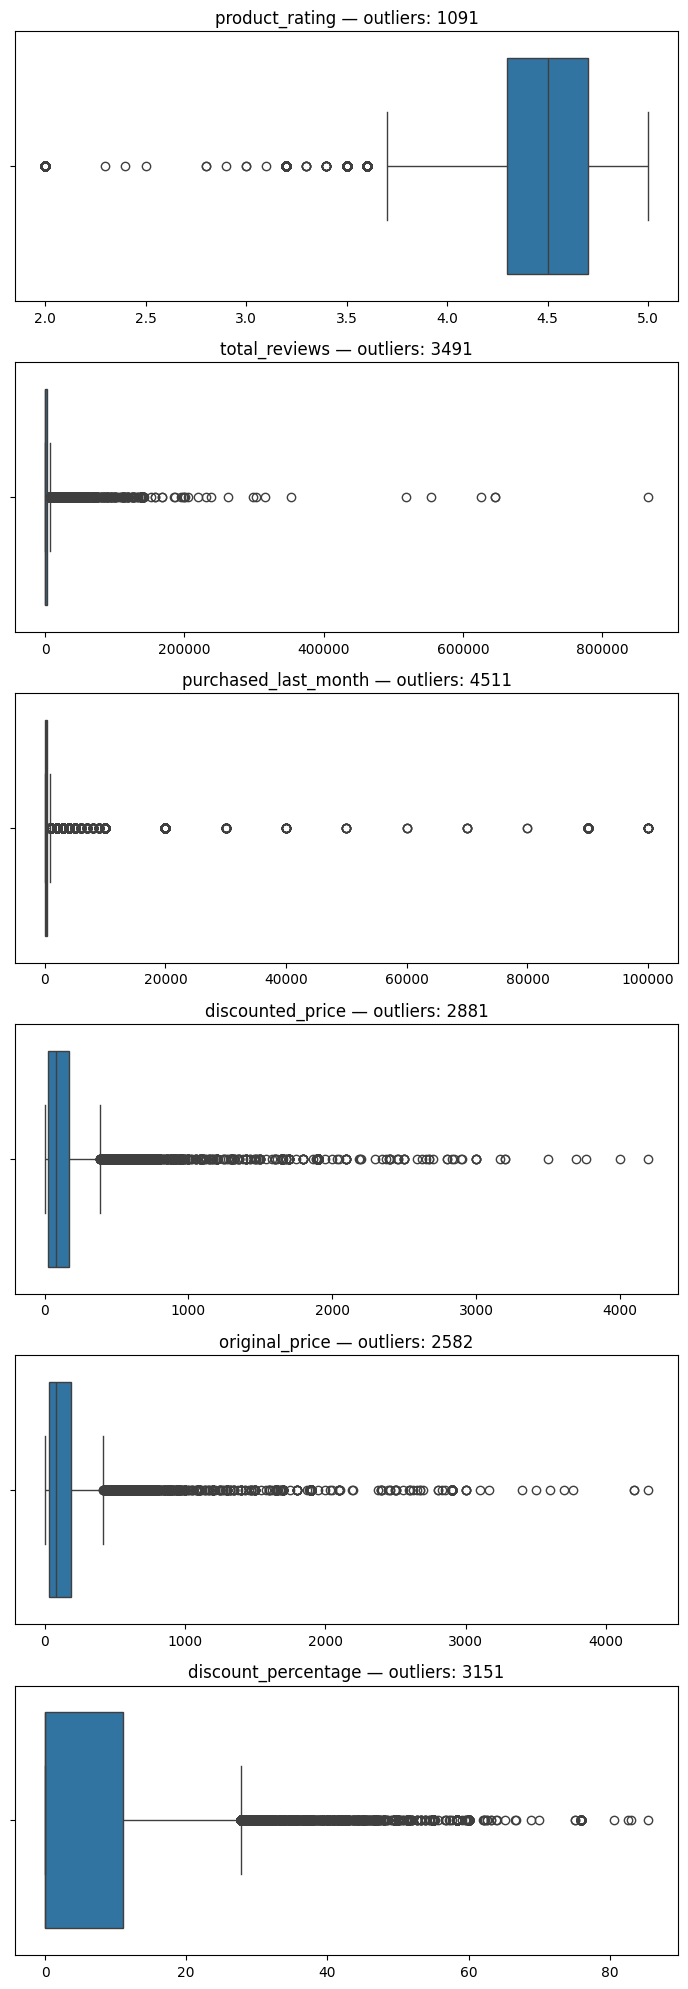

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(6,1, figsize=(7, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    minimum = max(data.min(), lower_bound)
    maximum = min(data.max(), upper_bound)

    outlier_mask = (data < minimum) | (data > maximum)
    outlier_count = int(outlier_mask.sum())

    sns.boxplot(x=data, ax=axes[i])
    axes[i].set_title(f"{col} — outliers: {outlier_count}")
    axes[i].set_xlabel('')


plt.tight_layout()
plt.show()

## Outlier handling 
- `purchased_last_month` and `total_reviews` → `log1p` variants.
- `original_price` and `discounted_price` → capped at 99th percentile and `log1p` variants.


In [133]:
import numpy as np

for col in ['purchased_last_month', 'total_reviews']:
    if col in df.columns:
        df[col] = np.log1p(df[col])
for col in ['original_price', 'discounted_price','discount_percentage']:
    if col in df.columns:
        p99 = df[col].quantile(0.99)
        df[col] = df[col].clip(upper=p99)



In [134]:
df.describe()

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage
count,32164.000000,32164.000000,32164.000000,32164.000000,32164.000000,32164.000000
mean,4.422839,6.442963,5.396987,148.770254,161.564557,7.323159
std,0.366935,2.019204,1.363389,224.970884,252.147011,13.026987
min,2.000000,0.693147,3.931826,2.160000,2.160000,0.000000
25%,4.300000,5.049856,4.615121,25.655000,29.990000,0.000000
50%,4.500000,6.532334,5.303305,78.990000,78.990000,0.000000
75%,4.700000,7.895808,5.993961,168.992500,185.000000,11.110000
max,5.000000,13.671177,11.512935,1586.400000,1699.990000,58.380000


Index(['product_rating', 'total_reviews', 'purchased_last_month',
       'discounted_price', 'original_price', 'discount_percentage'],
      dtype='object')


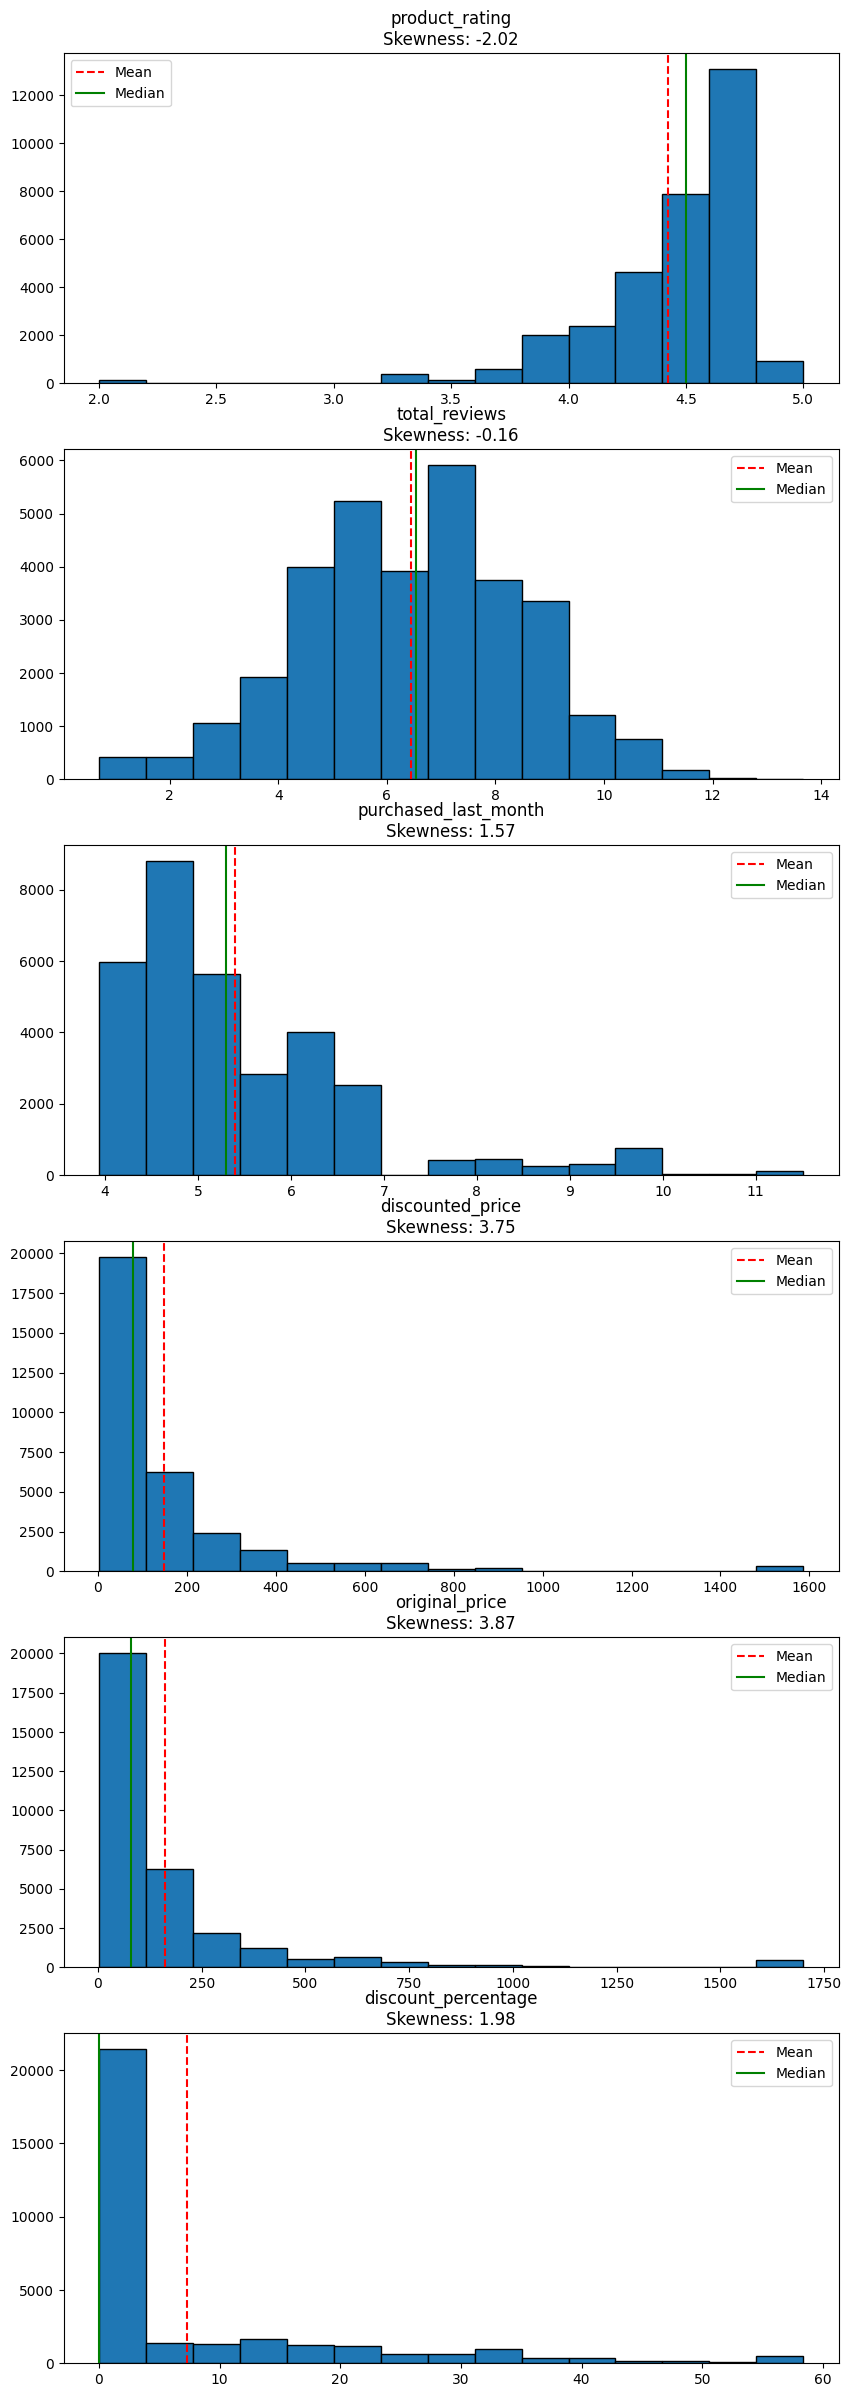

In [135]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=[np.number]).columns
print(numeric_cols)
fig, axes = plt.subplots(6, 1, figsize=(10, 30))
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i, col in enumerate(numeric_cols):  
    axes[i].hist(df[col],bins=15, edgecolor='black')
    axes[i].set_title(f'{col}\nSkewness: {df[col].skew():.2f}')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[i].axvline(df[col].median(), color='green', label='Median')
    axes[i].legend()


plt.show()

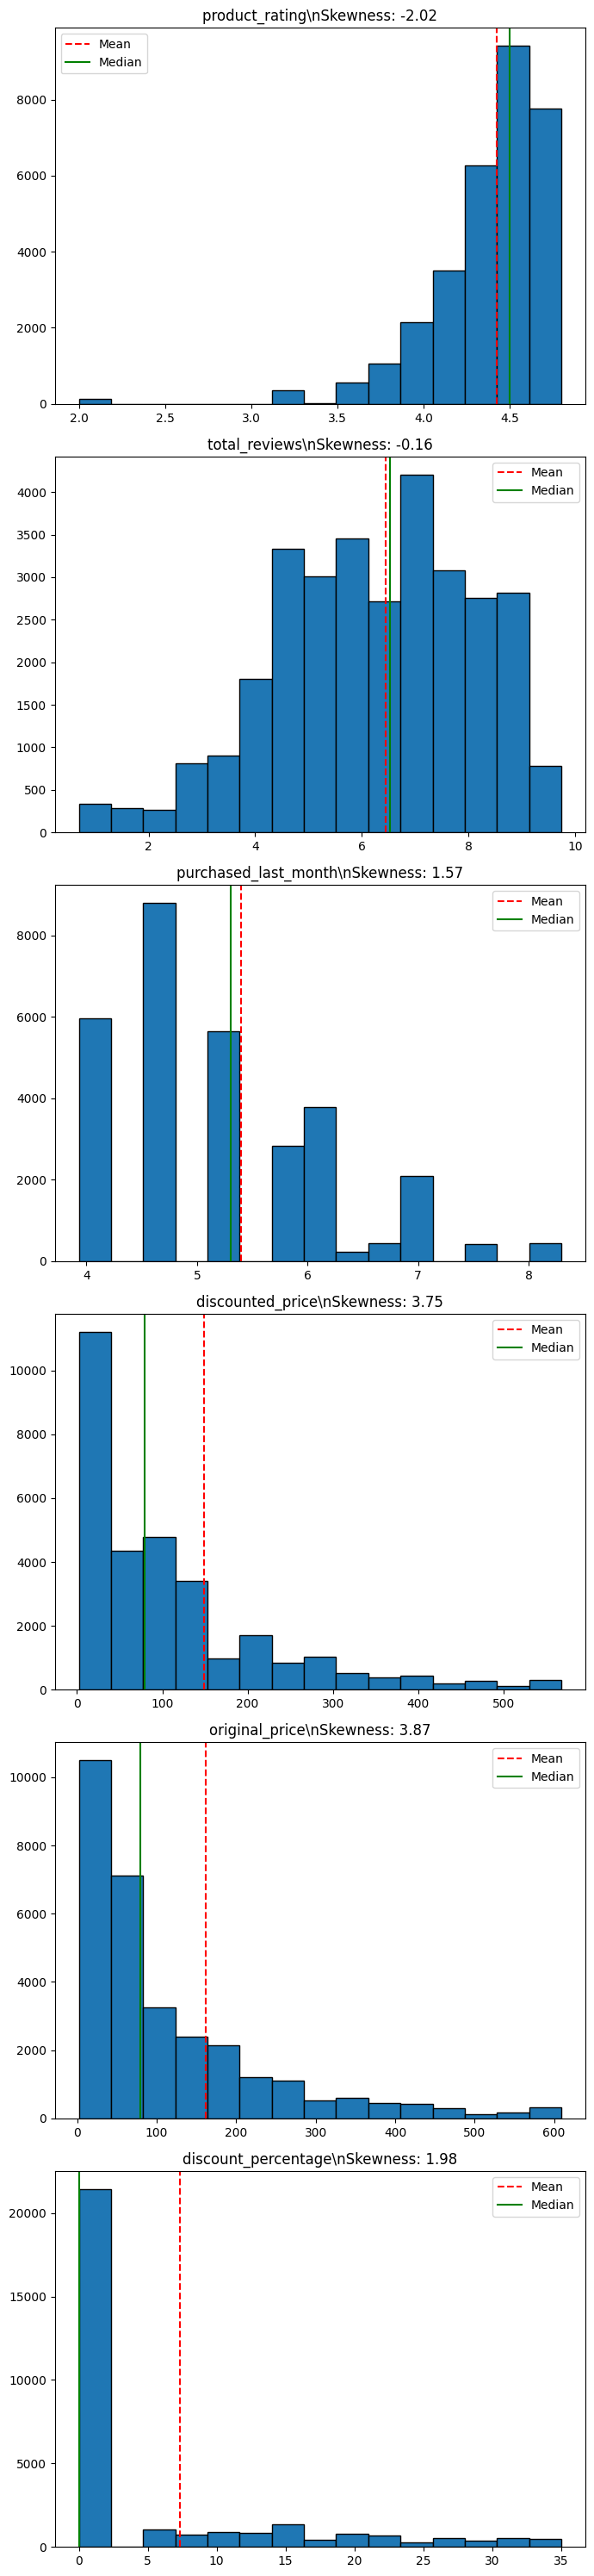

In [136]:
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
fig, axes = plt.subplots(6,1, figsize=(7, 30), squeeze=False)
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
        # optional: limit to 95th percentile to reduce outlier impact
    upper = data.quantile(0.95)
    data_plot = data[data <= upper]
    axes[i].hist(data_plot, bins=15, edgecolor='black')
    axes[i].set_title(f'{col}\\nSkewness: {data.skew():.2f}')
    axes[i].axvline(data.mean(), color='red', linestyle='--', label='Mean')
    axes[i].axvline(data.median(), color='green', label='Median')
    axes[i].legend()
plt.tight_layout()
plt.show()

# Encoding and Normalization


In [137]:
# 1. Separate target FIRST
y = df['purchased_last_month'].copy()

# 2. Drop irrelevant columns
X = df.drop(columns=['purchased_last_month', 'product_title', 'delivery_date', 'data_collected_at'])

# 3. Binary encoding
X['has_coupon'] = (X['has_coupon'] != 'No Coupon').astype(int)
X['is_best_seller'] = (X['is_best_seller'] != 'No Badge').astype(int)
X['is_sponsored'] = (X['is_sponsored'] == 'Sponsored').astype(int)
X['buy_box_availability'] = (X['buy_box_availability'] == 'Add to cart').astype(int)
X['sustainability_tags'] = (X['sustainability_tags'] != 'None').astype(int)

# 4. One-Hot Encode product_category
X = pd.get_dummies(X, columns=['product_category'])

# 5. Normalize numeric features
cols_to_normalize = ['product_rating', 'total_reviews', 'discounted_price', 
                     'original_price', 'discount_percentage']
for col in cols_to_normalize:
    if col in X.columns:
        X[col] = (X[col] - X[col].min()) / (X[col].max() - X[col].min())

print(X.shape)
print(X.isnull().sum().sum())  # should be 0
print(X.dtypes.value_counts()) # should be all numeric

(32164, 32)
0
bool       22
float64     5
int64       5
Name: count, dtype: int64


In [138]:
X

,product_rating,total_reviews,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,sustainability_tags,discount_percentage,...,product_category_Networking & Smart Home,product_category_Office Equipment,product_category_Other Electronics,product_category_Phones & Smartphones,product_category_Printers & Scanners,product_category_Protection Plans,product_category_Speakers & Audio,product_category_Storage & Memory,product_category_TVs & Displays,product_category_Tablets & E-Readers
0,0.866667,0.403485,0.055242,0.092377,0,1,1,1,1,0.746831,...,False,False,False,False,False,False,False,False,False,False
1,0.766667,0.548154,0.004943,0.008146,0,1,0,1,0,0.642686,...,False,False,False,False,False,False,False,False,False,False
2,0.866667,0.564655,0.196836,0.204284,0,1,0,1,0,0.171805,...,False,False,False,False,False,False,False,False,False,False
3,0.866667,0.754727,0.101045,0.094285,1,0,0,0,0,0.000000,...,False,False,False,False,False,False,False,False,False,False
4,0.933333,0.738288,0.044551,0.041571,0,0,0,0,0,0.000000,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32159,1.000000,0.000000,0.122349,0.114163,0,0,0,0,0,0.000000,...,False,False,False,False,False,False,False,False,False,False
32160,0.733333,0.181181,0.055440,0.051731,0,0,1,1,0,0.000000,...,False,False,False,False,False,False,False,False,False,False
32161,0.766667,0.259461,0.566740,0.646608,1,0,0,1,0,0.311408,...,False,False,False,False,False,False,False,False,True,False
32162,0.900000,0.629920,0.005195,0.008140,0,0,0,1,0,0.599178,...,False,False,False,False,False,False,False,False,False,False


# Checking the data types

In [139]:
X.dtypes

product_rating                              float64
total_reviews                               float64
discounted_price                            float64
original_price                              float64
is_best_seller                                int64
is_sponsored                                  int64
has_coupon                                    int64
buy_box_availability                          int64
sustainability_tags                           int64
discount_percentage                         float64
product_category_Accessories                   bool
product_category_Appliances                    bool
product_category_Batteries                     bool
product_category_Cameras & Photography         bool
product_category_Cases & Protection            bool
product_category_Chargers & Power              bool
product_category_Computer Components           bool
product_category_Gaming                        bool
product_category_Headphones & Earbuds          bool
product_cate

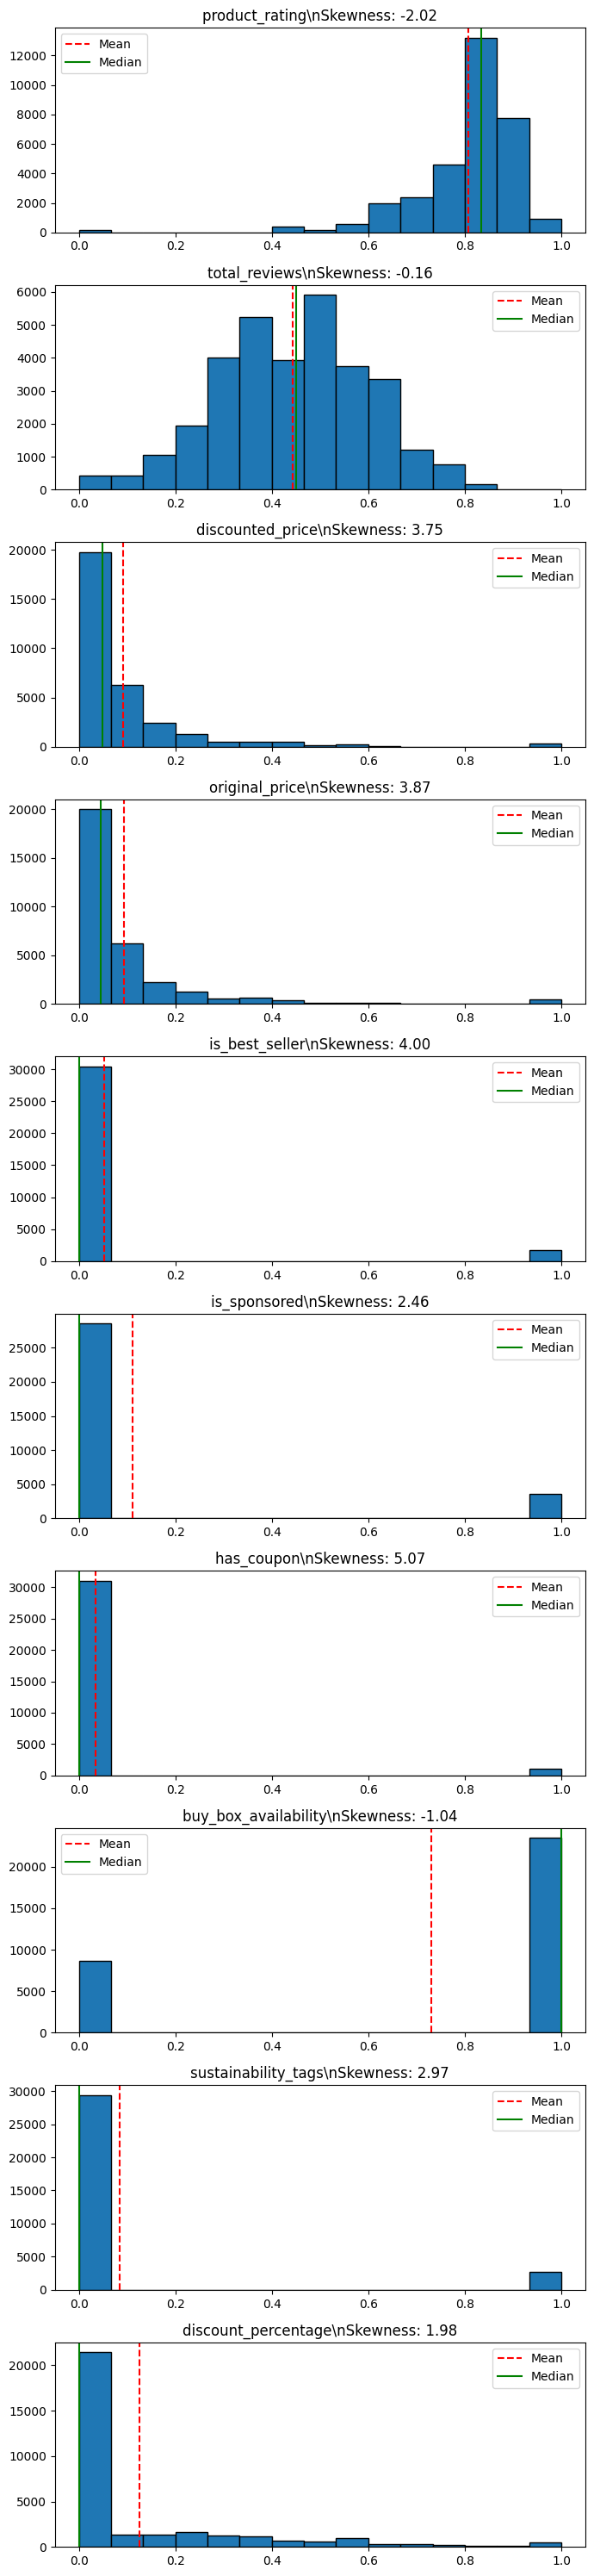

In [154]:
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
fig, axes = plt.subplots(10,1, figsize=(7, 30), squeeze=False)
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    data = X[col]
    
    axes[i].hist(data, bins=15, edgecolor='black')
    axes[i].set_title(f'{col}\\nSkewness: {data.skew():.2f}')
    axes[i].axvline(data.mean(), color='red', linestyle='--', label='Mean')
    axes[i].axvline(data.median(), color='green', label='Median')
    axes[i].legend()
plt.tight_layout()
plt.show()

In [141]:
# Check current state
print(df['has_coupon'].value_counts())
print(df['has_coupon'].dtype)

has_coupon
No Coupon                                    31043
Save 15%  with coupon                          398
Save 10%  with coupon                          193
Save 5%  with coupon                           190
Save $100.00  with coupon                       96
Save $25.00  with coupon                        65
Save $30.00  with coupon                        48
Save $69.00  with coupon                        31
Save 8%  with coupon                            18
Save $10.00  with coupon                        14
Save $18.00  with coupon                         8
Save $20.00  with coupon                         7
Save 20%  with coupon                            6
Save $15.00  with coupon                         5
Save $1.00  with coupon                          4
Save $12.00  with coupon                         3
Save $4.00  with coupon                          3
Save 40%  with coupon                            3
Save 25%  with coupon                            3
Save $2.00  with cou

# EDA Tasks

## 1. Target Variable Analysis (Product Demand)

Analyzing the distribution of `purchased_last_month` - our target variable for demand prediction.
 ## 1. Target Variable Analysis (Product Demand)
        a) Analyze distribution of purchased_last_month. 
        b) Identify: 
            High-demand vs low-demand products 
        c) Skewness and outliers

5.303304908059076
5.39698697521752


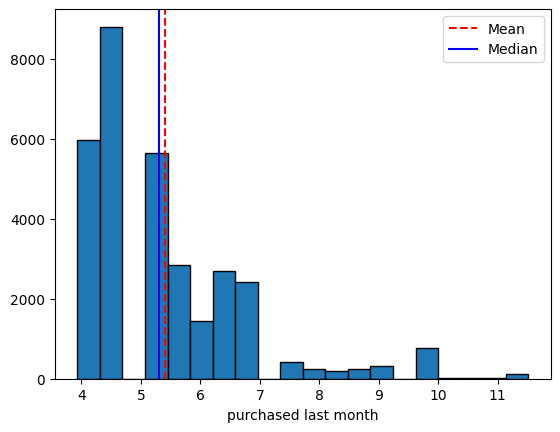

Skewness =  1.5652154603521267
Number of outliers: 1689
              product_category  purchased_last_month
1             Chargers & Power              8.699681
3         Headphones & Earbuds              9.210440
4      Networking & Smart Home              9.210440
5             Office Equipment             11.512935
6         Headphones & Earbuds              9.210440
...                        ...                   ...
31980                Batteries              8.699681
32046                Batteries              9.903538
32057                Batteries              8.699681
32081                Batteries              9.903538
32082                Batteries              8.699681

[1689 rows x 2 columns]


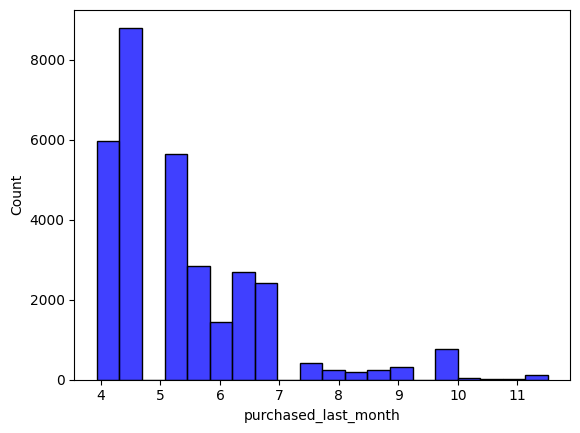

In [142]:
# 1. Target Variable Analysis (Product Demand) 
# ● Analyze distribution of purchased_last_month. 
# ● Identify: 
# ○ High-demand vs low-demand products 
# # ○ Skewness and outliers 

plt.hist(df['purchased_last_month'],bins=20, edgecolor='black')
plt.xlabel('purchased last month')
plt.axvline(df['purchased_last_month'].mean(),color='red',linestyle='--',label='Mean')
plt.axvline(df['purchased_last_month'].median(),color='blue',label='Median')
print(df['purchased_last_month'].median())
print(df['purchased_last_month'].mean())
plt.legend()
plt.show()
plt.clf()
skewness=df['purchased_last_month'].skew()
print("Skewness = ",skewness)
# Calculate Q1, Q3, and IQR
Q1 = df['purchased_last_month'].quantile(0.25)
Q3 = df['purchased_last_month'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['purchased_last_month'] < lower_bound) | (df['purchased_last_month'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")
print(outliers[['product_category', 'purchased_last_month']])

sns.histplot(df['purchased_last_month'],  color='blue', bins=20)
plt.show()


0        5.707110
1        8.699681
2        7.601402
3        9.210440
4        9.210440
           ...   
32159    4.615121
32160    5.303305
32161    3.931826
32162    6.216606
32163    3.931826
Name: purchased_last_month, Length: 32164, dtype: float64
product_category
Chargers & Power           23662.045111
Other Electronics          19762.310969
Batteries                  18832.369580
Printers & Scanners        12693.120513
Microphones                10666.398773
Cameras & Photography      10300.517714
Laptops & Computers        10040.924451
Gaming                      8054.430565
Headphones & Earbuds        7712.743453
Speakers & Audio            7488.973002
TVs & Displays              6922.204418
Computer Components         6837.680612
Phones & Smartphones        6188.960268
Networking & Smart Home     4637.872870
Accessories                 3996.649731
Keyboards & Mice            3898.986881
Cases & Protection          3278.914201
Storage & Memory            3168.447749
Tablets

<Axes: xlabel='product_category'>

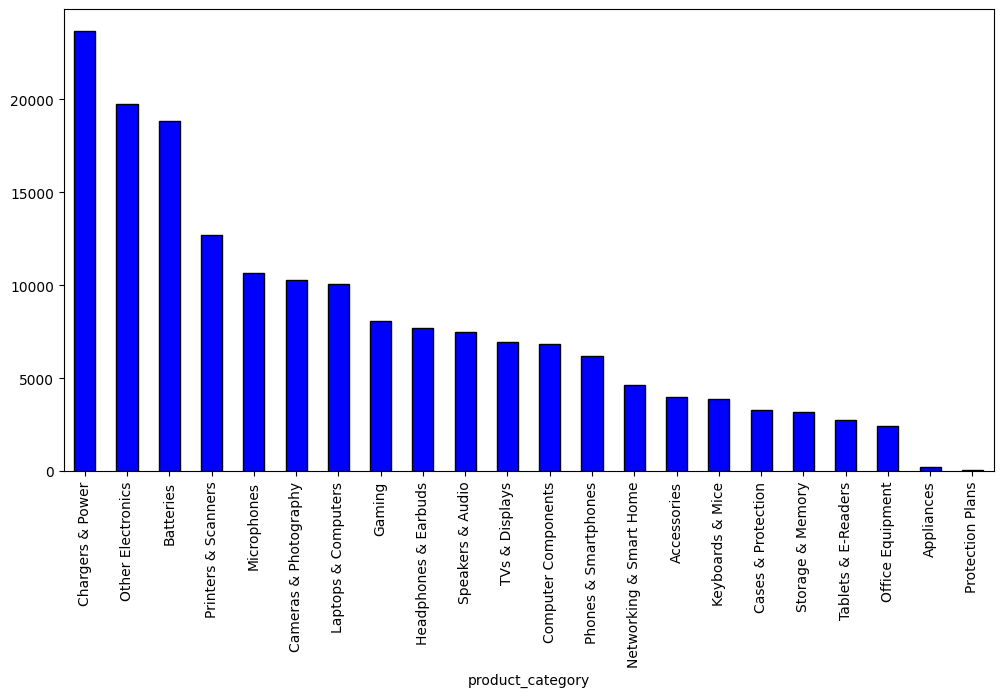

In [143]:
print(df['purchased_last_month'])
category_data=df.groupby('product_category')['purchased_last_month'].sum().sort_values(ascending=False)
print(category_data)
plt.figure(figsize=(12,6))
category_data.plot(kind='bar', color='blue', edgecolor='black')


# 2. Pricing & Discount Analysis 
## Analyze: 
* Original vs discounted price relationship 
* Discount percentage distribution 
## Identify how: 
* Higher discounts affect demand 
* Price ranges impact purchases 
## Compare demand for: 
* Discounted vs non-discounted products

[159.0, 15.99, 349.0, 162.24, 72.74, 99.95, 88.11, 23.04, 284.05, 14.99, 880.95, 29.99, 249.99, 69.95, 17.45, 39.97, 14.49, 16.98, 33.51, 19.98, 146.14, 14.33, 16.1, 78.99, 17.99, 21.89, 9.54, 43.89, 35.89, 20.0, 11.06, 48.99, 78.99, 19.99, 29.95, 148.0, 38.98, 14.39, 21.89, 169.99, 19.99, 29.99, 219.99, 280.12, 17.97, 15.0, 24.99, 25.66, 127.49, 476.5, 79.99, 97.49, 47.89, 32.72, 71.87, 514.28, 12.69, 169.99, 106.89, 17.99, 39.59, 1647.21, 44.99, 485.05, 154.89, 18.99, 69.95, 569.95, 21.44, 29.99, 13.45, 540.75, 11.98, 135.0, 199.99, 99.95, 103.99, 166.62, 55.89, 15.68, 49.99, 33.99, 39.99, 89.99, 119.97, 33.99, 35.64, 24.58, 69.99, 39.99, 249.99, 27.99, 6.91, 6.29, 239.99, 62.89, 229.99, 169.0, 32.29, 34.99, 85.89, 60.5, 348.0, 65.99, 5.84, 32.72, 62.89, 176.99, 67.89, 26.99, 96.89, 27.99, 78.99, 96.99, 39.99, 97.99, 18.9, 919.08, 99.99, 69.95, 49.99, 24.83, 93.89, 549.15, 89.0, 11.87, 43.29, 64.99, 159.95, 45.79, 20.79, 109.99, 8.99, 32.99, 184.99, 43.09, 23.74, 67.2, 13.29, 171.13,

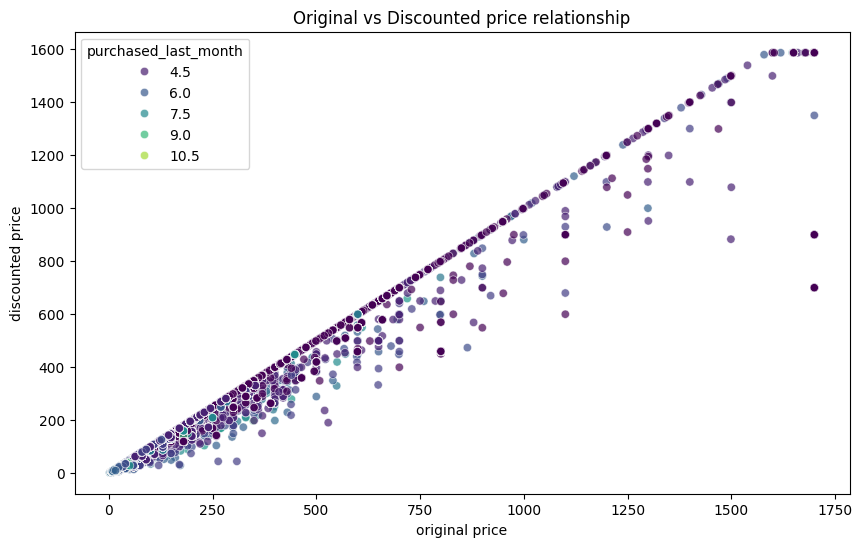

In [144]:
original_price=df['original_price'].tolist()
print(original_price)
discounted_price=df['discounted_price'].tolist()
print(discounted_price)
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='original_price', y='discounted_price', hue='purchased_last_month', palette='viridis', alpha=0.7)
plt.title('Original vs Discounted price relationship')
plt.xlabel('original price')
plt.ylabel('discounted price')
plt.show()

Text(0.5, 0, 'discount_percentage')

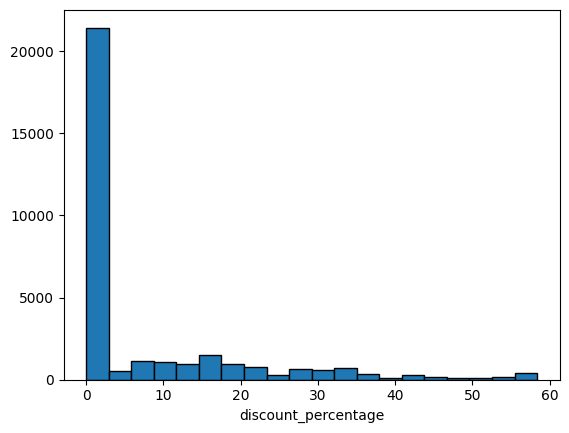

In [145]:
discount_percentage=df['discount_percentage'].tolist()
plt.hist(discount_percentage,edgecolor='black',bins=20)
plt.xlabel('discount_percentage')

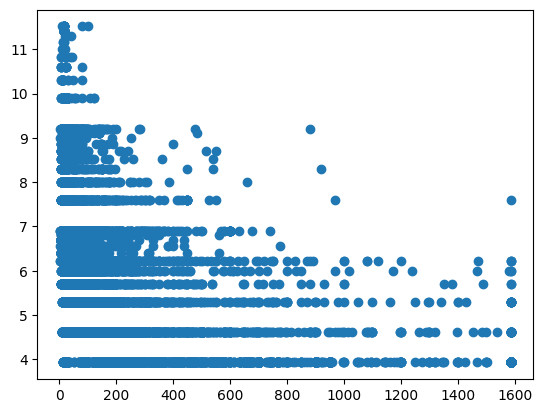

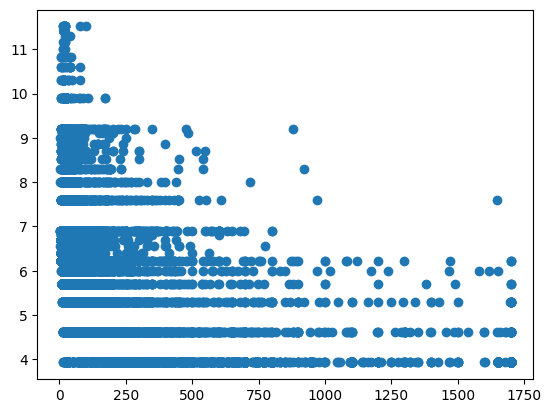

In [146]:

purchased_last_month=df['purchased_last_month'].tolist()
plt.scatter(discounted_price,purchased_last_month)
plt.show()
plt.clf()

plt.scatter(original_price,purchased_last_month)
plt.show()

=== DISCOUNT PERCENTAGE IMPACT ON DEMAND ===
discount_bin
0-10%     11824.017290
10-20%    22773.989200
20-30%    10762.627485
30-40%     8505.825294
40-50%     3621.465794
50%+       3524.071527
Name: purchased_last_month, dtype: float64


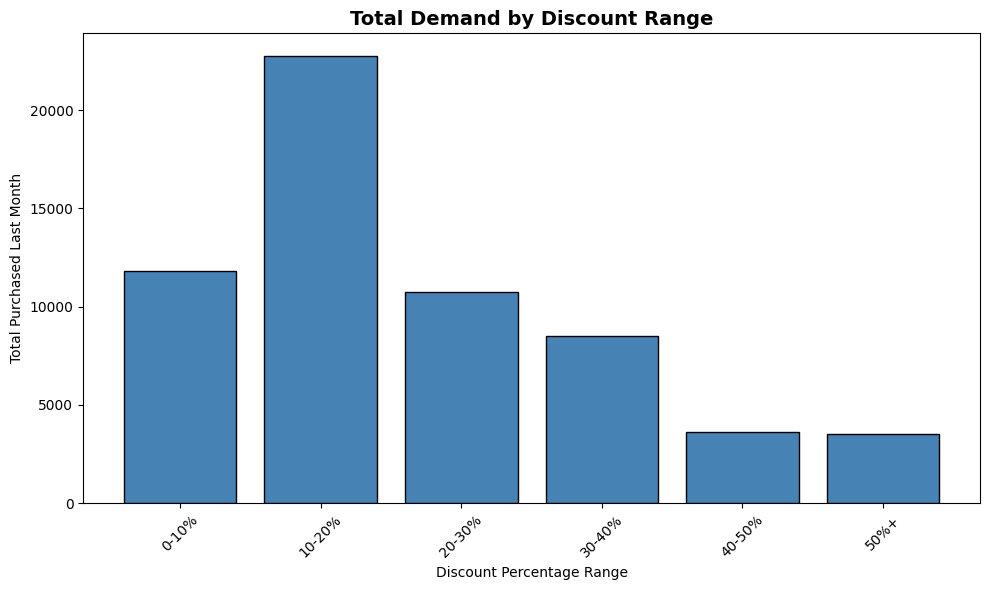

In [147]:

discount_bins = [0, 10, 20, 30, 40, 50, 100]
discount_labels = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50%+']
df['discount_bin'] = pd.cut(df['discount_percentage'], bins=discount_bins, labels=discount_labels)

discount_demand = df.groupby('discount_bin', observed=True)['purchased_last_month'].sum()

print('=== DISCOUNT PERCENTAGE IMPACT ON DEMAND ===')
print(discount_demand)

# Bar plot
plt.figure(figsize=(10, 6))
plt.bar(discount_demand.index, discount_demand.values, color='steelblue', edgecolor='black')
plt.title('Total Demand by Discount Range', fontsize=14, fontweight='bold')
plt.xlabel('Discount Percentage Range')
plt.ylabel('Total Purchased Last Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== PRICE RANGE IMPACT ON DEMAND ===
price_range
Budget      56017.013119
Economy     45341.509283
Standard    36928.404242
Premium     35301.762427
Name: purchased_last_month, dtype: float64


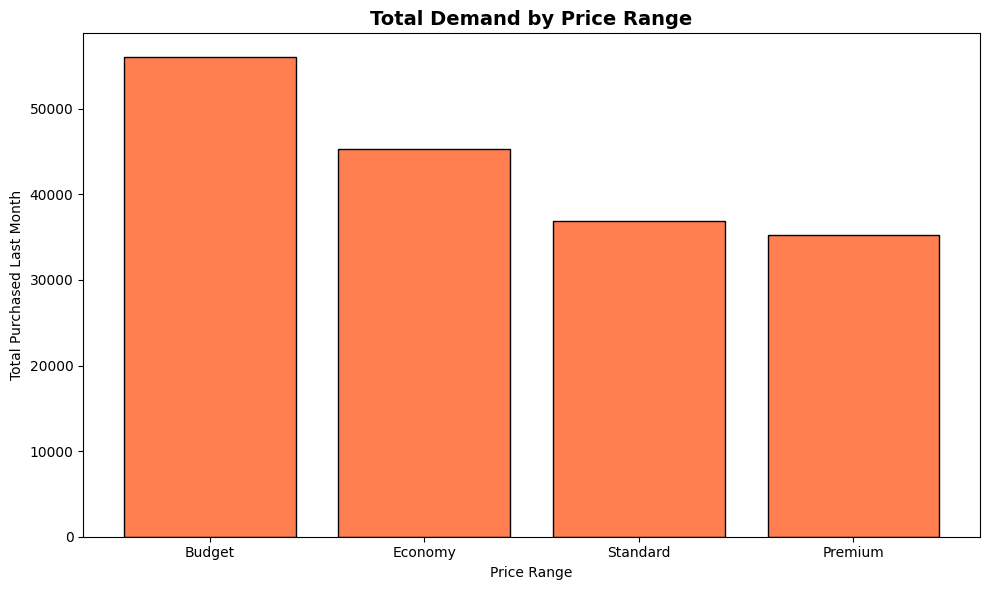

In [148]:
# How Price Ranges Impact Purchases

# Create price bins based on quartiles
price_quartiles = df['original_price'].quantile([0.25, 0.5, 0.75])
price_bins = [df['original_price'].min(), price_quartiles[0.25], price_quartiles[0.5], price_quartiles[0.75], df['original_price'].max()]
price_labels = ['Budget', 'Economy', 'Standard', 'Premium']
df['price_range'] = pd.cut(df['original_price'], bins=price_bins, labels=price_labels, include_lowest=True)

# Calculate total demand by price range
price_demand = df.groupby('price_range', observed=True)['purchased_last_month'].sum()

print('=== PRICE RANGE IMPACT ON DEMAND ===')
print(price_demand)

# Bar plot
plt.figure(figsize=(10, 6))
plt.bar(price_demand.index, price_demand.values, color='coral', edgecolor='black')
plt.title('Total Demand by Price Range', fontsize=14, fontweight='bold')
plt.xlabel('Price Range')
plt.ylabel('Total Purchased Last Month')
plt.tight_layout()
plt.show()

Not Discounted: 21449 products, Total demand: 112576.69
Discounted:     10715 products, Total demand: 61012.00


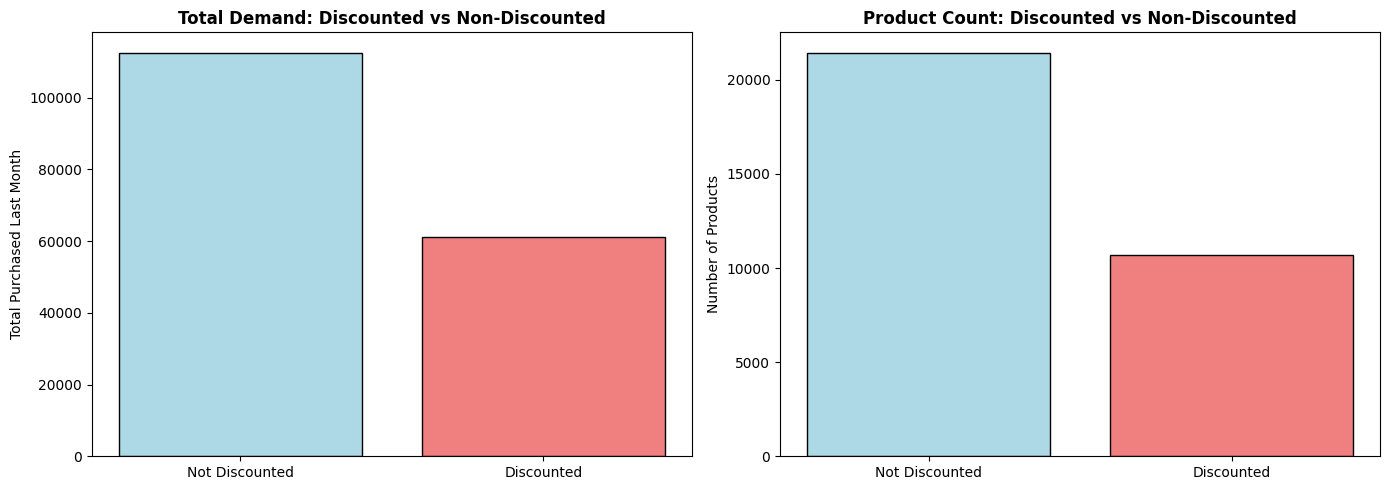

In [149]:
# Compare Demand: Discounted vs Non-Discounted Products

not_disc = df[df['discount_percentage'] == 0]
disc = df[df['discount_percentage'] > 0]

total_demands = [not_disc['purchased_last_month'].sum(), disc['purchased_last_month'].sum()]
counts = [len(not_disc), len(disc)]
categories = ['Not Discounted', 'Discounted']

print(f'Not Discounted: {counts[0]} products, Total demand: {total_demands[0]:.2f}')
print(f'Discounted:     {counts[1]} products, Total demand: {total_demands[1]:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(categories, total_demands, color=['lightblue', 'lightcoral'], edgecolor='black')
axes[0].set_title('Total Demand: Discounted vs Non-Discounted', fontweight='bold')
axes[0].set_ylabel('Total Purchased Last Month')

axes[1].bar(categories, counts, color=['lightblue', 'lightcoral'], edgecolor='black')
axes[1].set_title('Product Count: Discounted vs Non-Discounted', fontweight='bold')
axes[1].set_ylabel('Number of Products')

plt.tight_layout()
plt.show()

# 3. Rating & Review Impact 
## Analyze relationship between: 
* Product rating and demand 
* Total reviews and demand 
## Identify threshold effects: 
* Minimum rating for high demand 
# Compare: 
* High-rating/low-review vs low-rating/high-review products

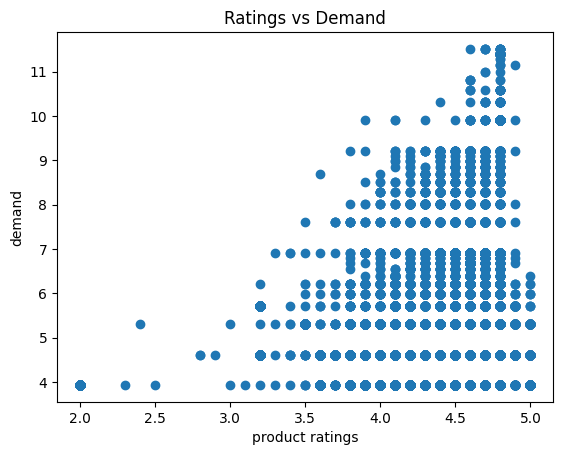

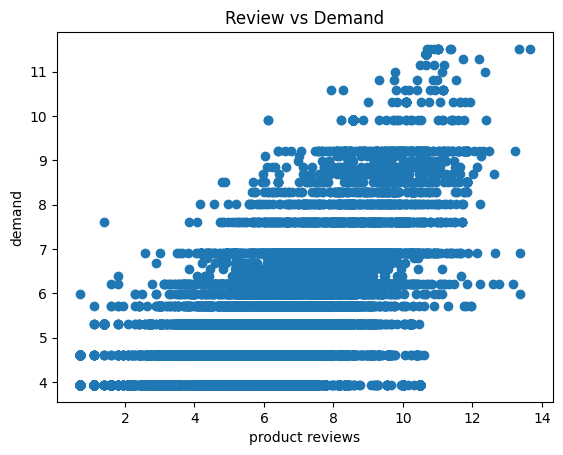

In [150]:
product_rating=df['product_rating'].tolist()
plt.scatter(product_rating,purchased_last_month)
plt.title('Ratings vs Demand')
plt.xlabel('product ratings')
plt.ylabel('demand')
plt.show()
plt.clf()
plt.title('Review vs Demand')
product_review=df['total_reviews'].tolist()
plt.scatter(product_review,purchased_last_month)
plt.xlabel('product reviews')
plt.ylabel('demand')
plt.show()

In [151]:
# Minimum rating for high demand
demand_threshold = df['purchased_last_month'].quantile(0.75)  # top 25% demand
high_demand = df[df['purchased_last_month'] >= demand_threshold]
min_rating_high_demand = high_demand['product_rating'].min()

print(f"High-demand threshold (75th percentile): {demand_threshold}")
print(f"Minimum rating among high-demand products: {min_rating_high_demand}")
print(f"High-demand product count: {len(high_demand)}")

High-demand threshold (75th percentile): 5.993961427306569
Minimum rating among high-demand products: 3.2
High-demand product count: 8909


=== BEST SELLER IMPACT ===
is_best_seller
Amazon's               4085.714979
Best Seller            2157.786565
Ends in                 554.675155
Limited time deal      2820.804077
No Badge             162831.105556
Save 12%                102.227466
Save 17%                235.371146
Save 18%                224.114061
Save 30%                576.890065
Name: purchased_last_month, dtype: float64

=== SPONSORED IMPACT ===
is_sponsored
Organic      147739.094147
Sponsored     25849.594924
Name: purchased_last_month, dtype: float64

=== COUPON IMPACT ===
has_coupon
No Coupon                                    166768.505885
Save $0.33  with coupon                           9.903538
Save $1.00  with coupon                          30.406608
Save $1.50  with coupon                          15.203054
Save $10.00  with coupon                         82.587878
Save $100.00  with coupon                       380.597135
Save $11.00  with coupon                          5.993961
Save $12.00  with

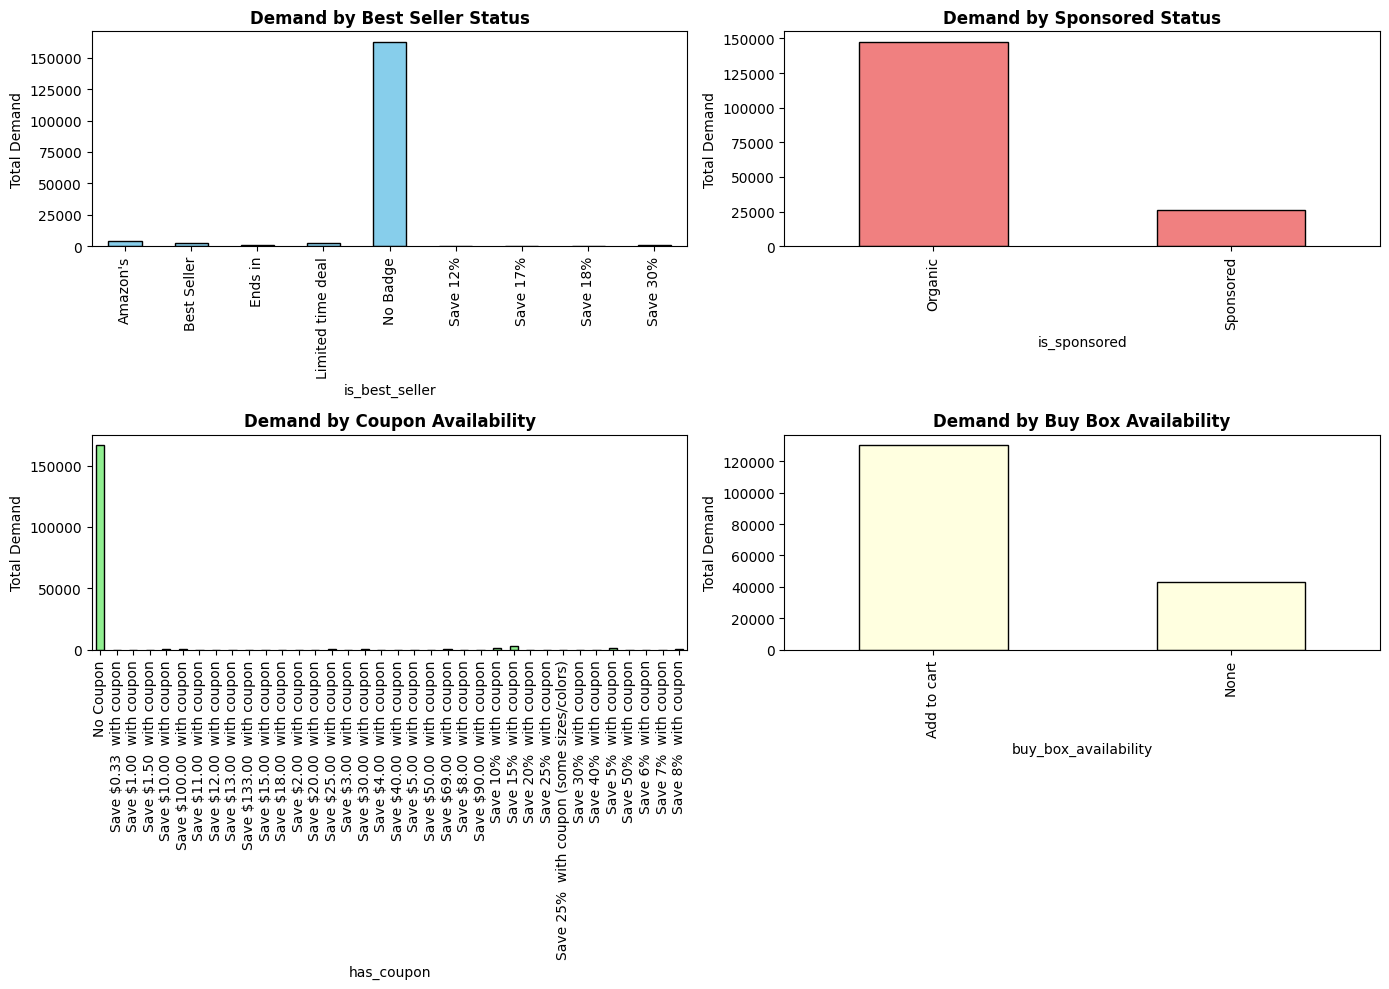

In [152]:
# 4. PROMOTION & VISIBILITY ANALYSIS

# Best Seller Status
best_seller_demand = df.groupby('is_best_seller')['purchased_last_month'].sum()
print('=== BEST SELLER IMPACT ===')
print(best_seller_demand)

# Sponsored Products
sponsored_demand = df.groupby('is_sponsored')['purchased_last_month'].sum()
print('\n=== SPONSORED IMPACT ===')
print(sponsored_demand)

# Coupons
coupon_demand = df.groupby('has_coupon')['purchased_last_month'].sum()
print('\n=== COUPON IMPACT ===')
print(coupon_demand)

# Buy Box Availability
buybox_demand = df.groupby('buy_box_availability')['purchased_last_month'].sum()
print('\n=== BUY BOX AVAILABILITY IMPACT ===')
print(buybox_demand)

# Simple bar plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

best_seller_demand.plot(kind='bar', ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Demand by Best Seller Status', fontweight='bold')
axes[0, 0].set_ylabel('Total Demand')

sponsored_demand.plot(kind='bar', ax=axes[0, 1], color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Demand by Sponsored Status', fontweight='bold')
axes[0, 1].set_ylabel('Total Demand')

coupon_demand.plot(kind='bar', ax=axes[1, 0], color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Demand by Coupon Availability', fontweight='bold')
axes[1, 0].set_ylabel('Total Demand')

buybox_demand.plot(kind='bar', ax=axes[1, 1], color='lightyellow', edgecolor='black')
axes[1, 1].set_title('Demand by Buy Box Availability', fontweight='bold')
axes[1, 1].set_ylabel('Total Demand')

plt.tight_layout()
plt.show()

=== DEMAND BY CATEGORY ===
                                  sum      mean  count
product_category                                      
Chargers & Power         23662.045111  5.617769   4212
Other Electronics        19762.310969  5.162568   3828
Batteries                18832.369580  7.781971   2420
Printers & Scanners      12693.120513  5.245091   2420
Microphones              10666.398773  5.218395   2044
Cameras & Photography    10300.517714  5.152835   1999
Laptops & Computers      10040.924451  4.700807   2136
Gaming                    8054.430565  4.721237   1706
Headphones & Earbuds      7712.743453  5.271868   1463
Speakers & Audio          7488.973002  5.136470   1458
TVs & Displays            6922.204418  4.923332   1406
Computer Components       6837.680612  4.991008   1370
Phones & Smartphones      6188.960268  5.641714   1097
Networking & Smart Home   4637.872870  5.079817    913
Accessories               3996.649731  5.177007    772
Keyboards & Mice          3898.986881 

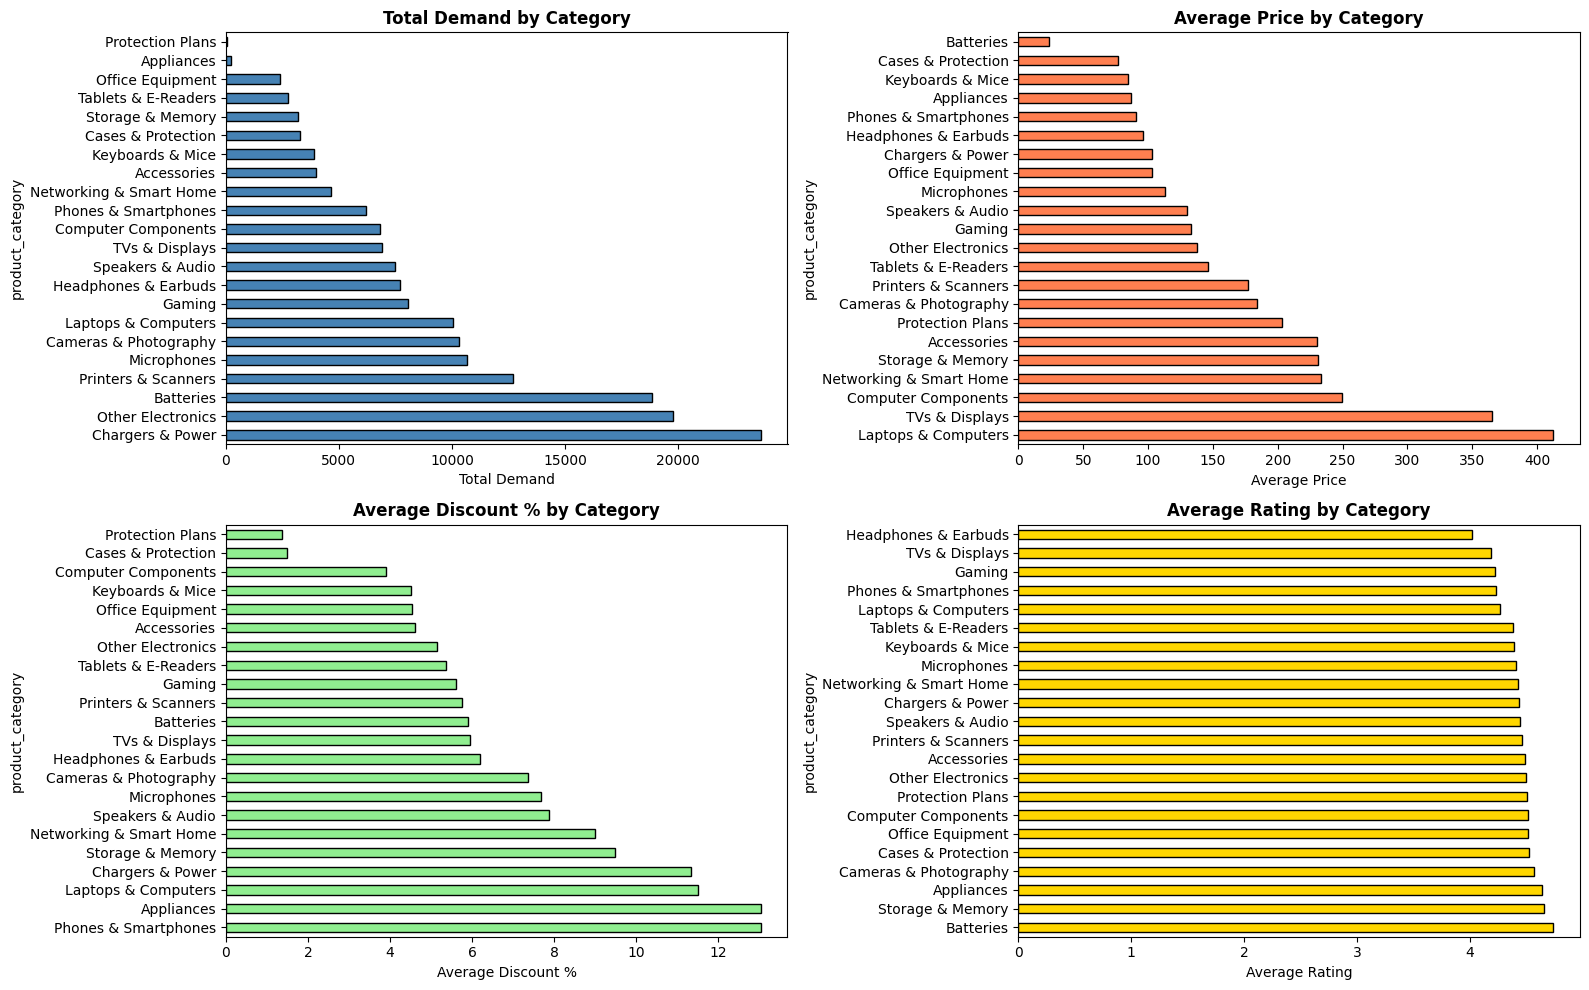

In [153]:
# 5. CATEGORY-LEVEL DEMAND ANALYSIS

# Demand by category
category_demand = df.groupby('product_category')['purchased_last_month'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)
print('=== DEMAND BY CATEGORY ===')
print(category_demand)

# Average price by category
category_price = df.groupby('product_category')['original_price'].mean().sort_values(ascending=False)
print('\n=== AVERAGE PRICE BY CATEGORY ===')
print(category_price)

# Average discount by category
category_discount = df.groupby('product_category')['discount_percentage'].mean().sort_values(ascending=False)
print('\n=== AVERAGE DISCOUNT BY CATEGORY ===')
print(category_discount)

# Average rating by category
category_rating = df.groupby('product_category')['product_rating'].mean().sort_values(ascending=False)
print('\n=== AVERAGE RATING BY CATEGORY ===')
print(category_rating)

# Simple bar plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

category_demand['sum'].plot(kind='barh', ax=axes[0, 0], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Total Demand by Category', fontweight='bold')
axes[0, 0].set_xlabel('Total Demand')

category_price.plot(kind='barh', ax=axes[0, 1], color='coral', edgecolor='black')
axes[0, 1].set_title('Average Price by Category', fontweight='bold')
axes[0, 1].set_xlabel('Average Price')

category_discount.plot(kind='barh', ax=axes[1, 0], color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Average Discount % by Category', fontweight='bold')
axes[1, 0].set_xlabel('Average Discount %')

category_rating.plot(kind='barh', ax=axes[1, 1], color='gold', edgecolor='black')
axes[1, 1].set_title('Average Rating by Category', fontweight='bold')
axes[1, 1].set_xlabel('Average Rating')

plt.tight_layout()
plt.show()